In [1]:
import sys
import os
import torch
#import triton
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches
import torch
import copy
from simu_PSF_polarMFM import *
from extract_experimental_psf import *
from tqdm import tqdm
import time
from torch.optim import SGD, Adam, AdamW
import torch.nn.functional as F
import re

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using GPU


In [3]:
d = np.array([2.,2.,2.])
d = np.array([np.mean(d)-0.365, np.mean(d), np.mean(d)+0.365])
QE = 0.92
EM = 200
sensitivity = 15.4
polar_projections = np.array([0, 45, 0])

In [4]:
def limit(x, lim, slope, upper=True):
    '''
    if upper:
       return torch.sum(torch.tensor(1/(1+torch.exp(-slope*(x-lim))), requires_grad=True, device=device))
    else:
        return torch.sum(torch.tensor(1/(1+torch.exp(slope*(x-lim))), requires_grad=True, device=device))
    '''
    if upper:
        return torch.sum(torch.exp((x-lim)*slope))
    else:
        return torch.sum(torch.exp(-1*(x-lim)*slope))
    
def loss_pos_torch(xp, yp, zp, rho, eta, delta, N_photons, data, second_plane, background, sigma, dim_simu, plot):
    M_ = compute_M(xp=xp, yp=yp, zp=zp, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=None, zernike_coefs_x=None, zernike_coefs_y=None,
                        second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, 
                         device=device, mode=mode)
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]

    loss = torch.sum(torch.pow(torch.sum(torch.add(h+torch.reshape(background, (h.shape[0],3,2))[:, :, :, None, None], -data), dim=(2,)), 2))#/(torch.sum(h, dim=(2,))+sigma**2) + torch.log(torch.sum(h, dim=(2,))+sigma**2)

    x_bound = limit(xp, 5*0.12, 100, upper=True) + limit(xp, -5*0.12, 100, upper=False)
    y_bound = limit(yp, 5*0.12, 100, upper=True) + limit(yp, -5*0.12, 100, upper=False)
    z_bound = limit(zp, 5., 100, upper=True) + limit(zp, 0, 100, upper=False)
    N_bound = limit(N_photons, 0, 1, upper=False)
    return (loss +x_bound+y_bound+z_bound+N_bound).to(torch.float32)
#loss_pos = torch.compile(loss_pos_torch)
loss_pos = loss_pos_torch

def loss_angle_with_M_torch(rho, eta, delta, N_photons, x_fine, y_fine, z_fine, zernx, zerny, data, background, sigma, dim_simu):
    dim_data = 6
    M_ = compute_M(xp=x_fine, yp=y_fine, zp=z_fine, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_masky=phase_mask, phase_maskx=phase_mask, zernike_base=None, zernike_coefs_x=None, zernike_coefs_y=None,
                        second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, device=device, mode=mode)
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    
    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+torch.reshape(background, (h.shape[0],3,2))[:, :, :, None, None]+sigma**2)))
    #loss = torch.sum(torch.add(h, -(data)*torch.log(h)))
    delta_bound = limit(delta, 180, 100, upper=True) + limit(delta, 1, 100, upper=False)
    #eta_bound = limit(eta, 180, 100, upper=True) + limit(eta, 0, 100, upper=False)
    #rho_bound = limit(rho, 180, 100, upper=True) + limit(rho, 0, 100, upper=False)
    bb = torch.reshape(background, (h.shape[0],3,2))[:, :, :, None, None]
    #loss = torch.sum(torch.pow(torch.add(h+bb, -data), 2)/(h+bb+sigma**2) + torch.log(h+bb+sigma**2)) 
    return (loss + 1000.*(delta_bound)).to(torch.float32) #+ N_bound #+ 100000*torch.sum(h**2)
#loss_angle_with_M = torch.compile(loss_angle_with_M_torch)
loss_angle_with_M = loss_angle_with_M_torch

def score_eval(M_, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    score = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)), dim=(1,2,3,4))
    return score.numpy() 

In [5]:
def rot(angle):
    angle=angle*np.pi/180
    return np.array([[np.cos(angle), -np.sin(angle)],[np.sin(angle), np.cos(angle)]])

J1 = [[ 0.7997112        ,             -0.15173765 + 1j*  0.3638948 ],[
      -0.14405449 + 1j*  0.34023893  ,   -0.80568093 + 1j*  -0.032433655 ]]
J2 = [[ 0.49279398               ,      -0.696921 + 1j*  0.2615071 ],[
      0.21217652 + 1j*  0.6954243   ,  0.32051226 + 1j*  0.42396948 ]]
rotation = 14
J_dichroic = np.array([rot(-rotation)@J1@rot(rotation), rot(-rotation)@J2@rot(rotation), rot(-rotation)@J1@rot(rotation)])
#J_dichroic = np.array([J1, J2, J1])
mode='Stokes'

J_dichroic = np.array([np.array([[1,0],[0,1]]), rot(45)@np.array([[1,0],[0,1]]), np.array([[1,0],[0,1]])])

In [6]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [7]:
npsf = 100

In [8]:
N_photon_list = np.linspace(500, 10000, 20)

In [9]:
delta__=90

In [10]:
Nphotons_speed1 = 2000
background_speed = 100
LR1 = 0.04
num_epochs_max1 = 80

num_epochs_max2 = 280
LR2 = 1.
delta_speed = 1.8
nphotons_speed2 = 100
xy_speed2 = 1/70
z_speed2=1/20

/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/simu_PSF_polarMFM.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  costh2 = costh2.astype(float)
/home/amaury/exit/envs/env_linux/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


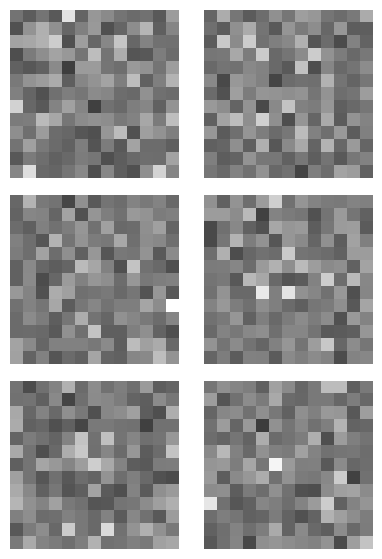

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.72it/s]


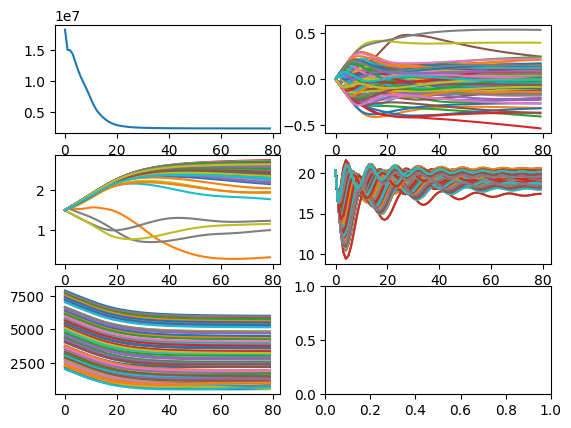

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.77it/s]


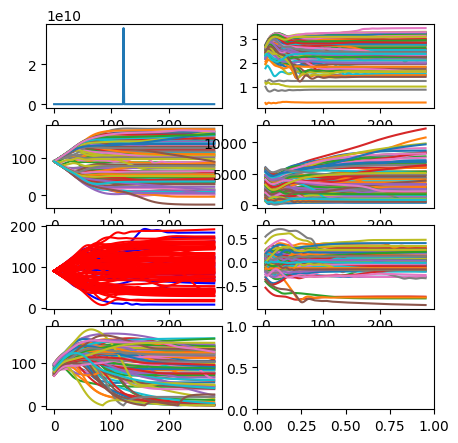

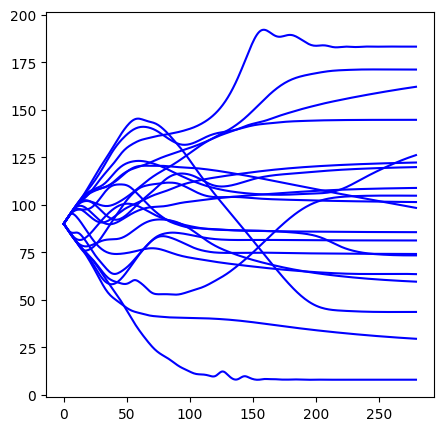

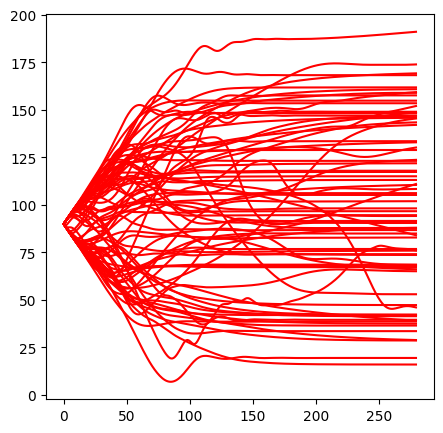

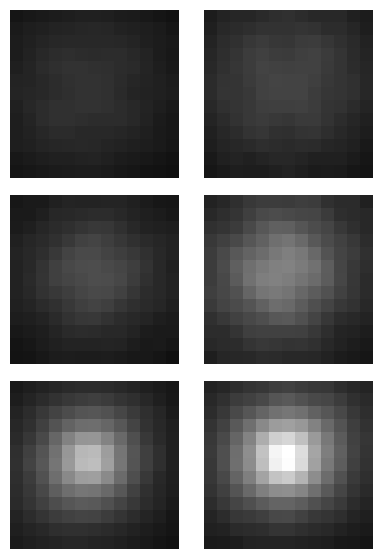

/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/simu_PSF_polarMFM.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  costh2 = costh2.astype(float)


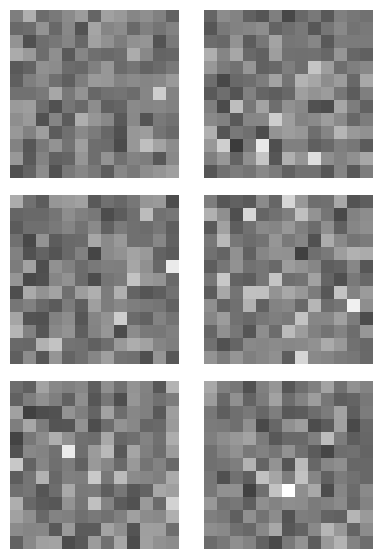

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.94it/s]


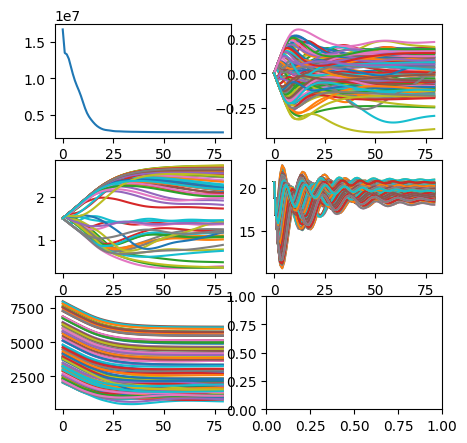

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.77it/s]


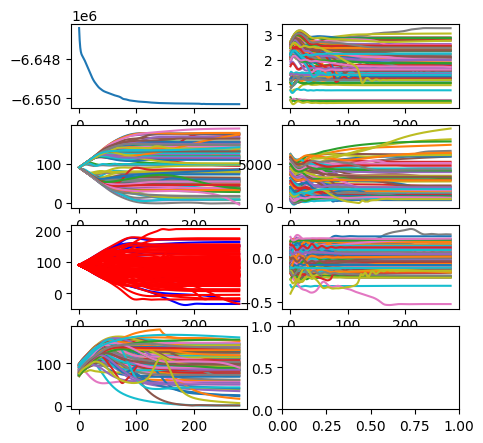

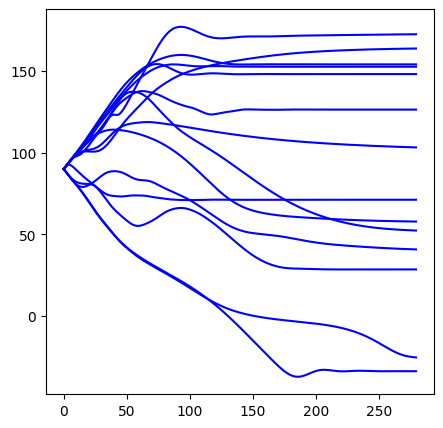

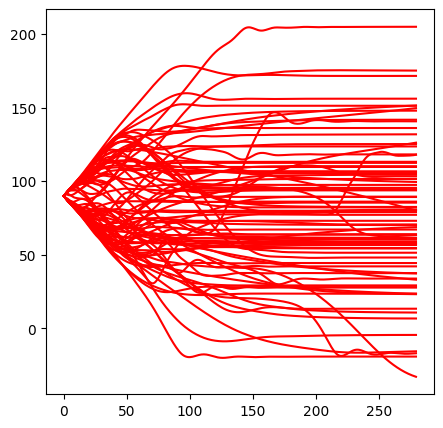

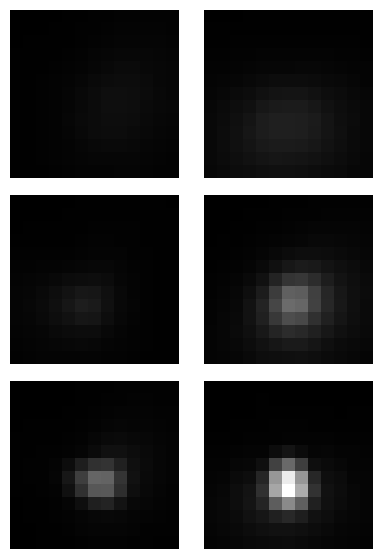

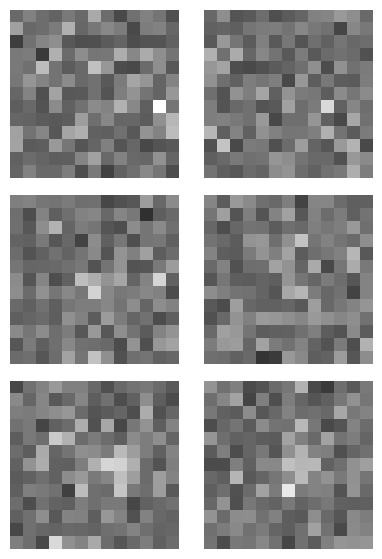

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.87it/s]


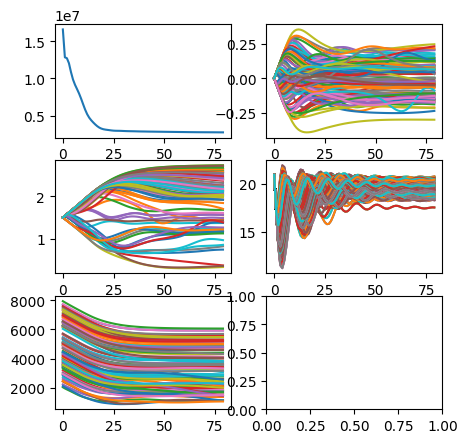

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.75it/s]


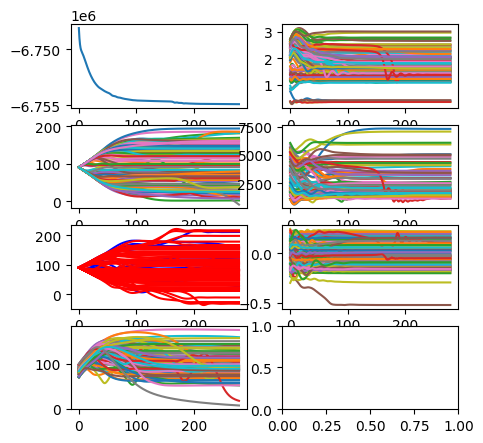

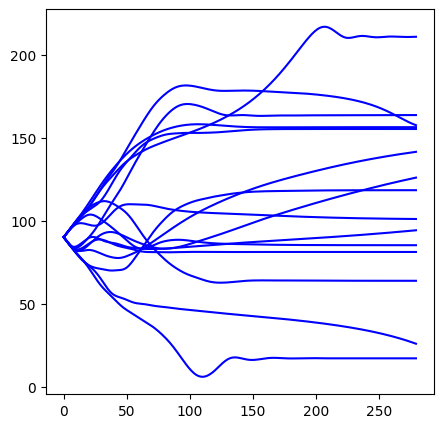

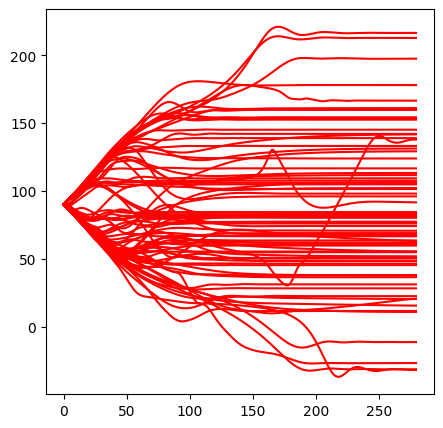

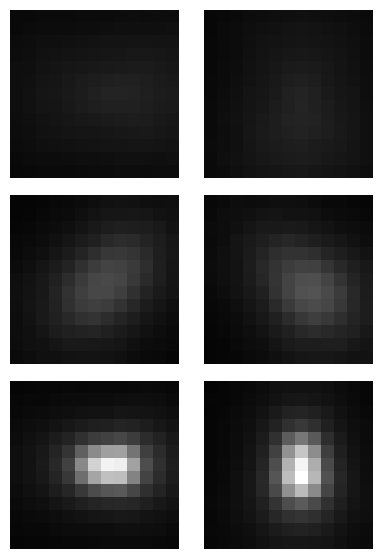

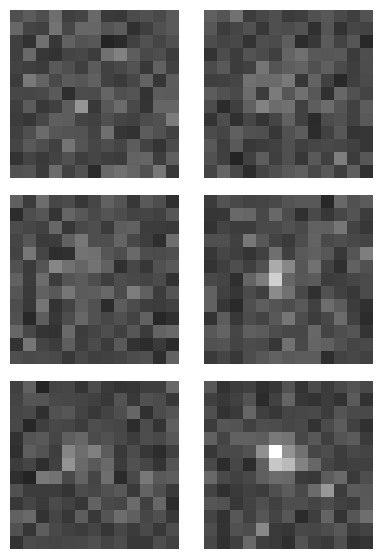

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.90it/s]


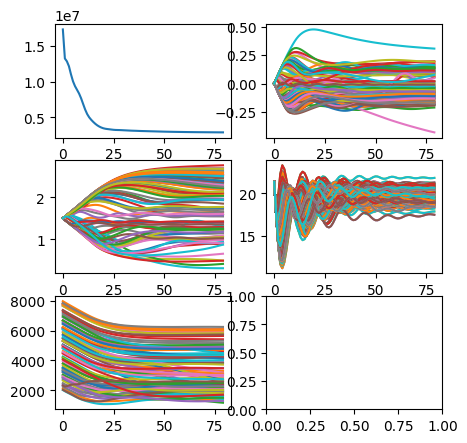

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:35<00:00,  7.79it/s]


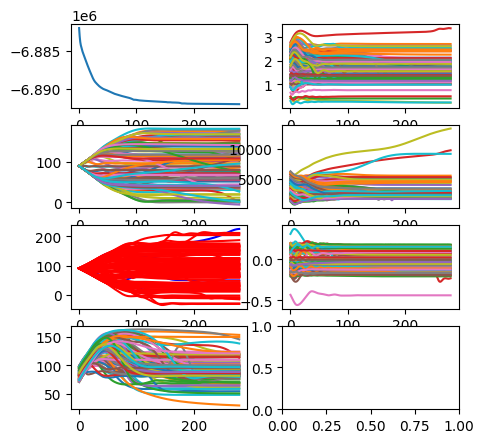

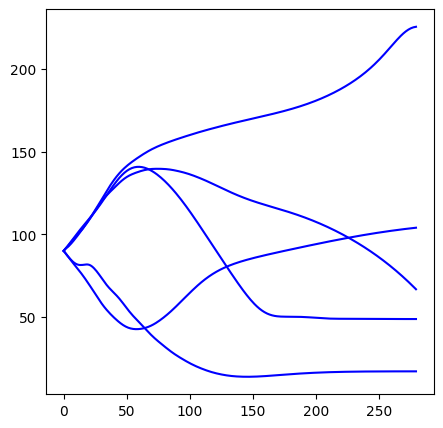

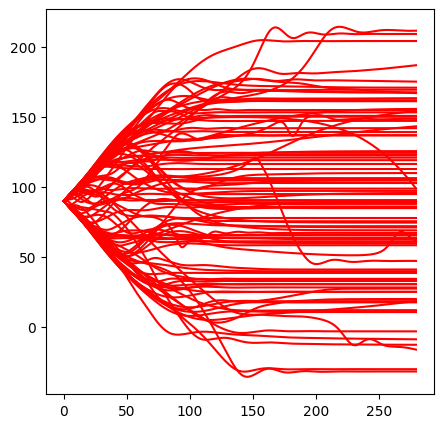

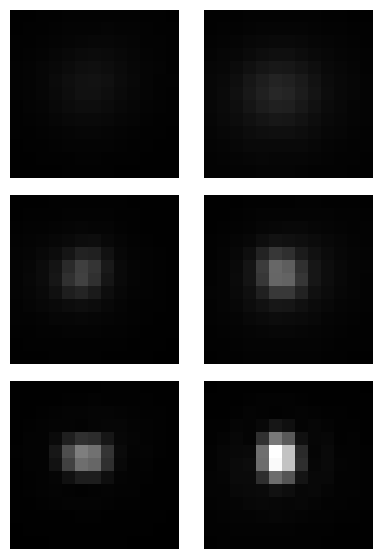

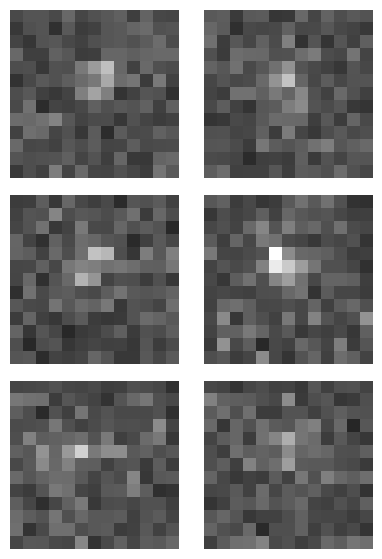

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.93it/s]


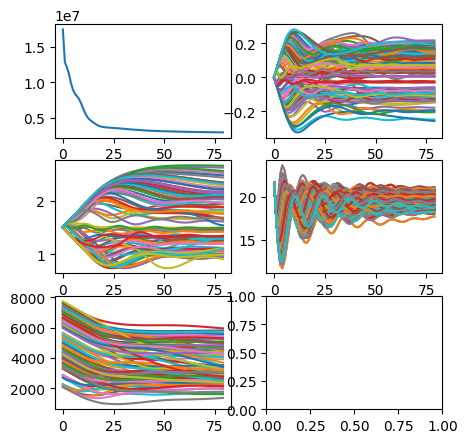

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.76it/s]


TypeError: 'int' object is not callable

<Figure size 500x500 with 8 Axes>

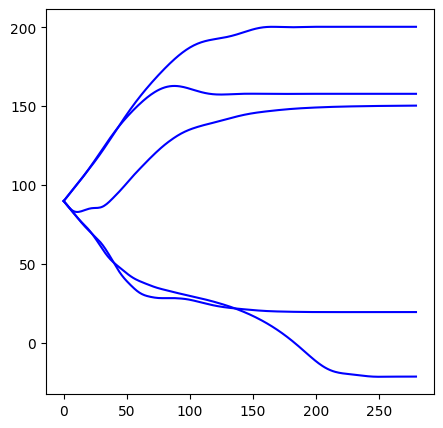

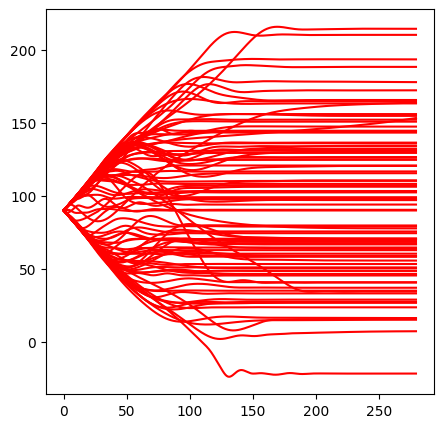

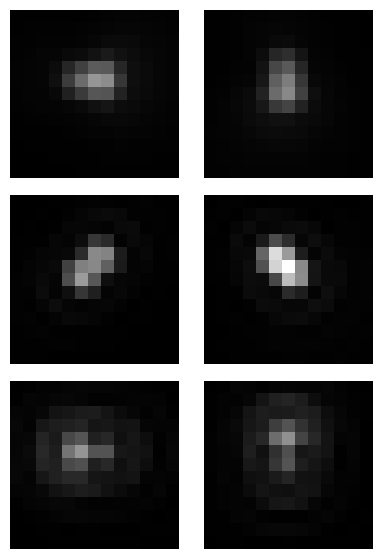

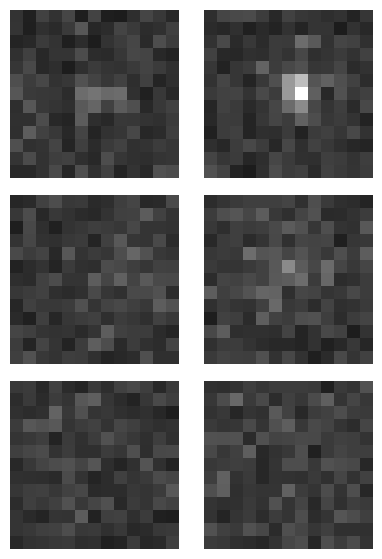

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.86it/s]


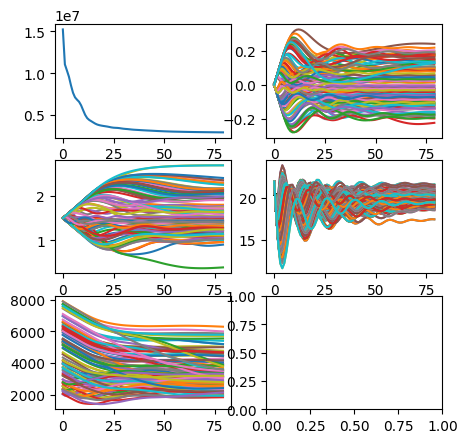

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.76it/s]


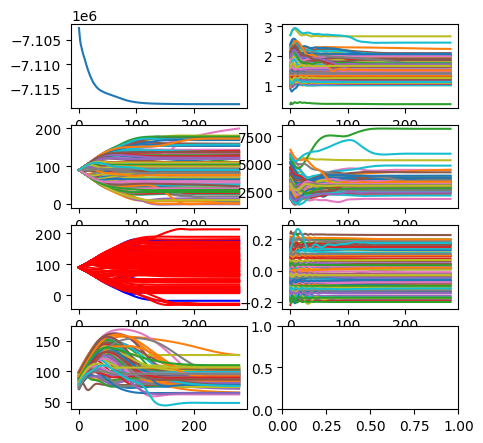

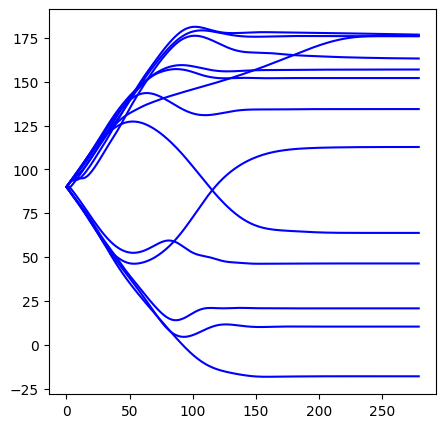

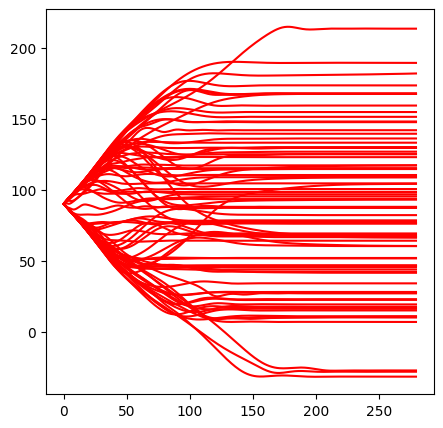

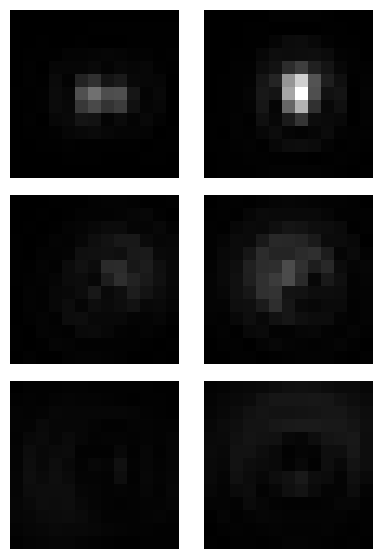

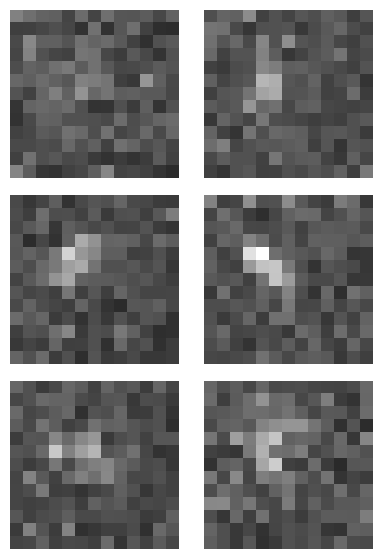

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.85it/s]


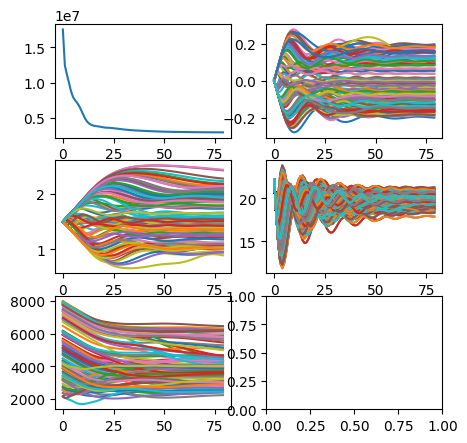

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.78it/s]


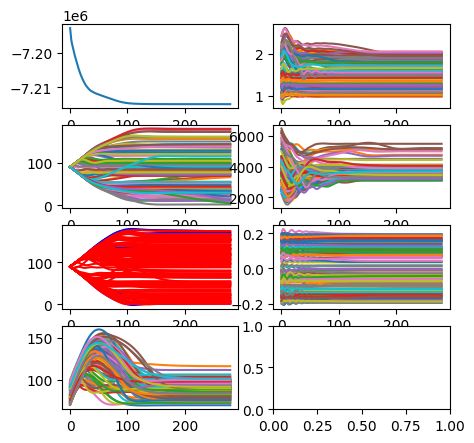

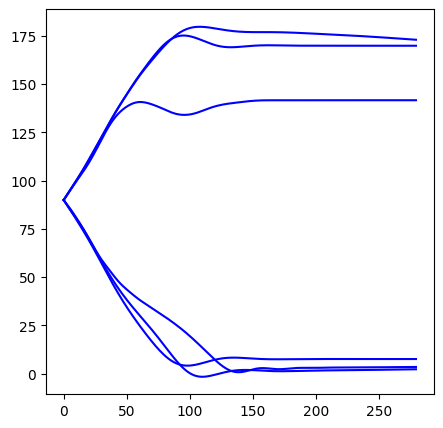

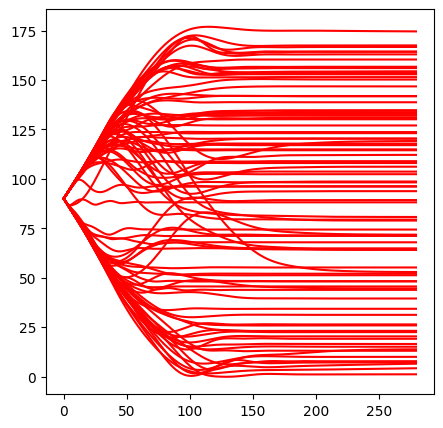

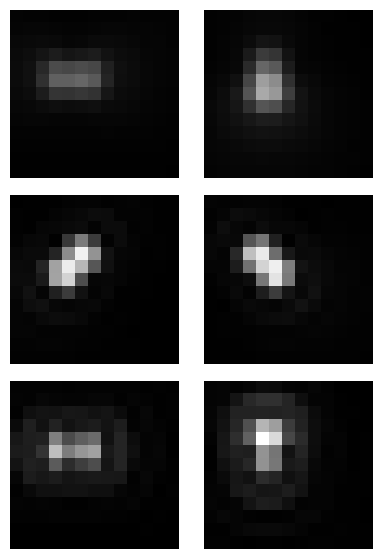

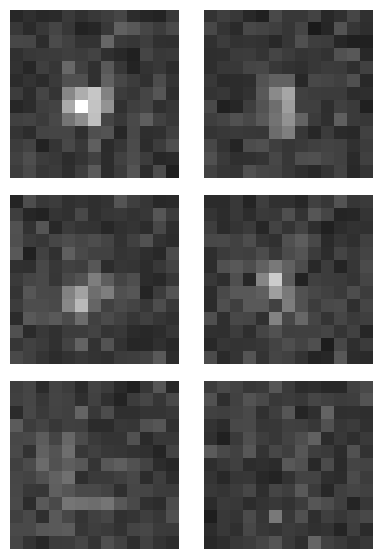

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.83it/s]


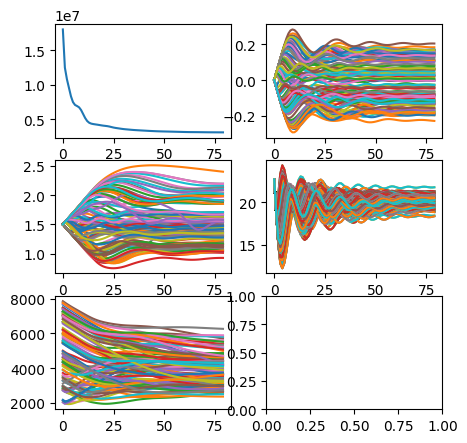

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.73it/s]


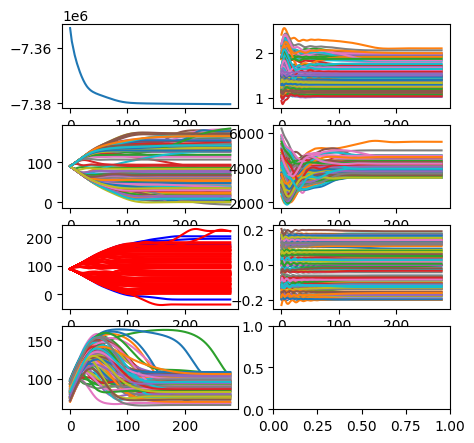

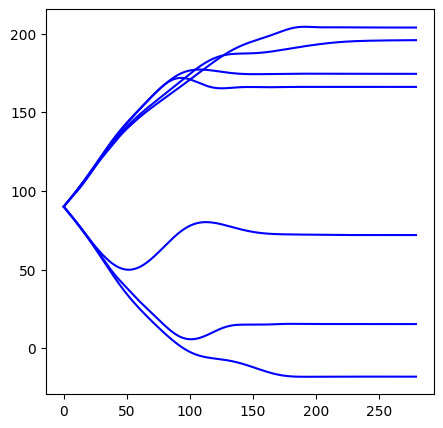

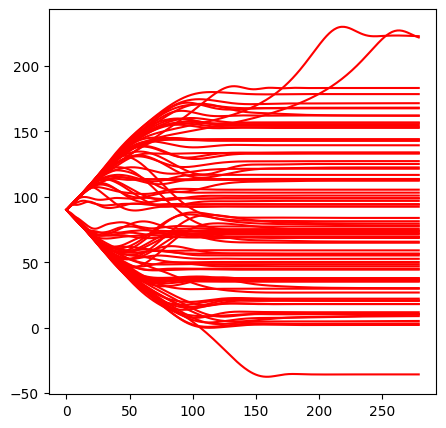

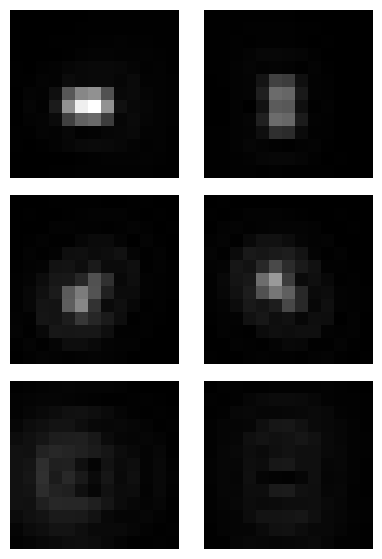

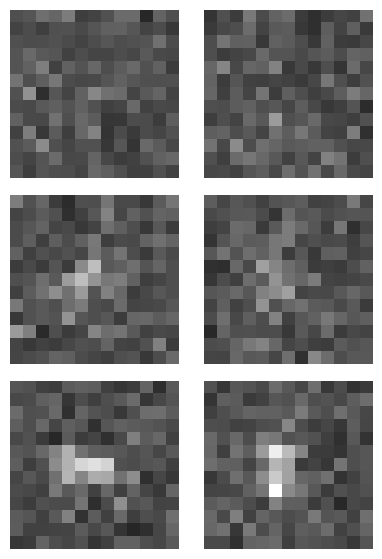

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.88it/s]


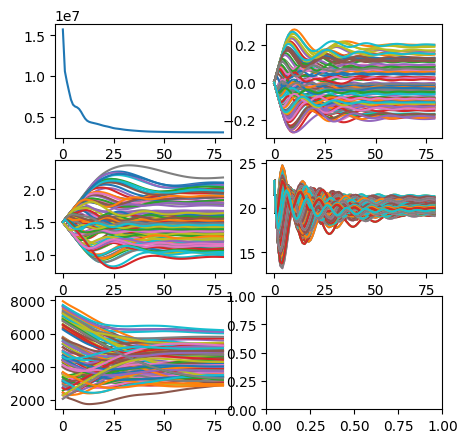

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.74it/s]


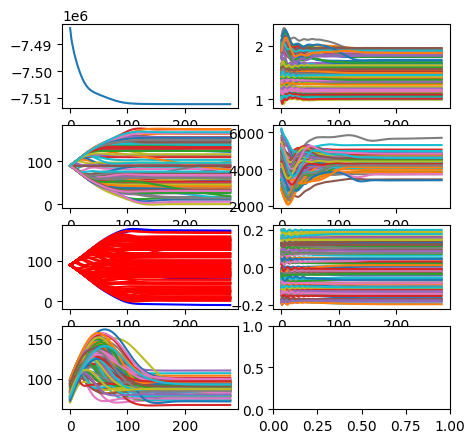

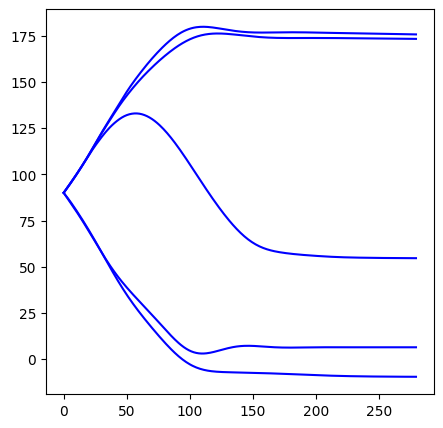

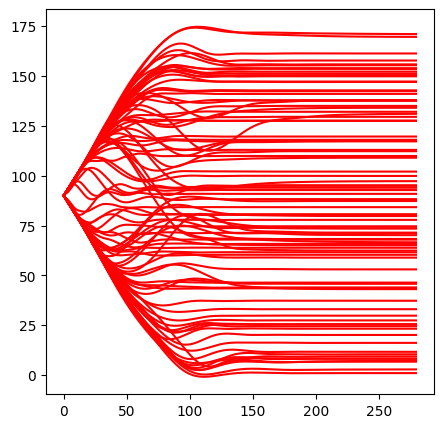

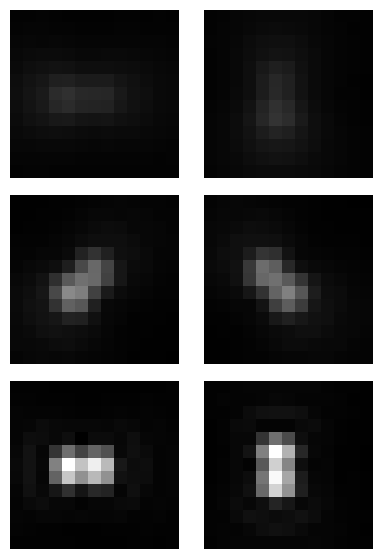

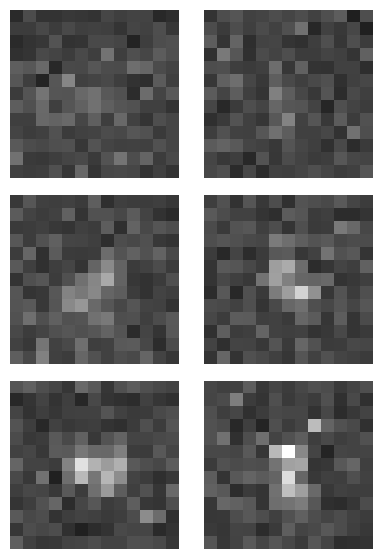

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.90it/s]


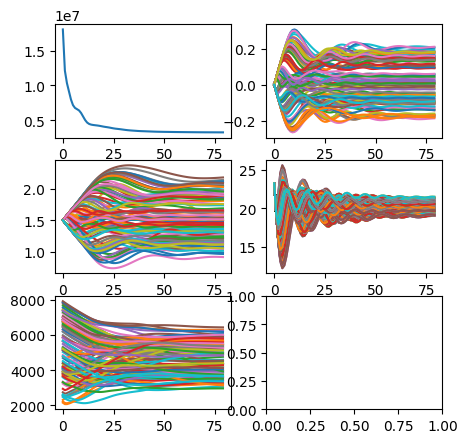

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.75it/s]


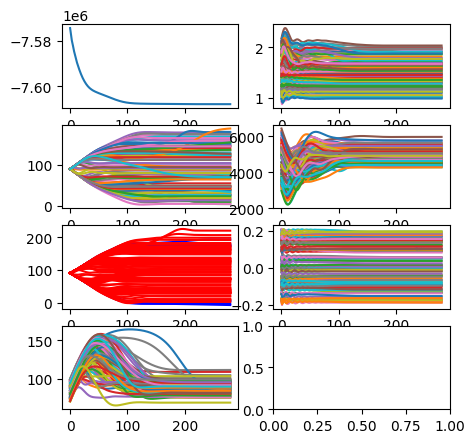

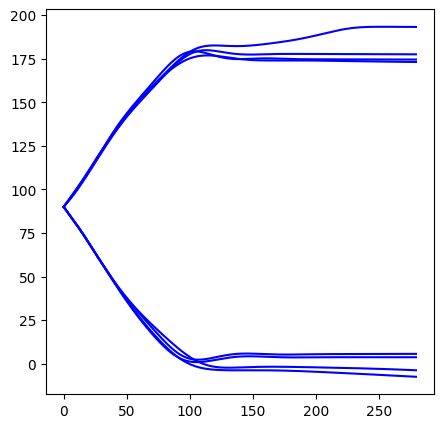

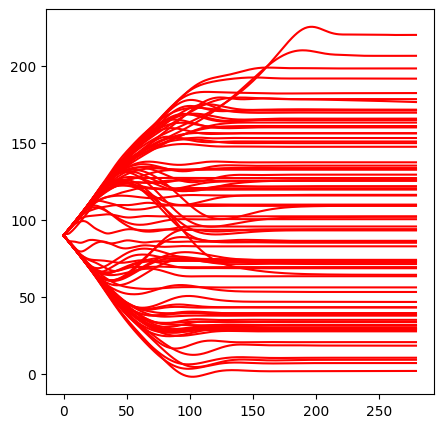

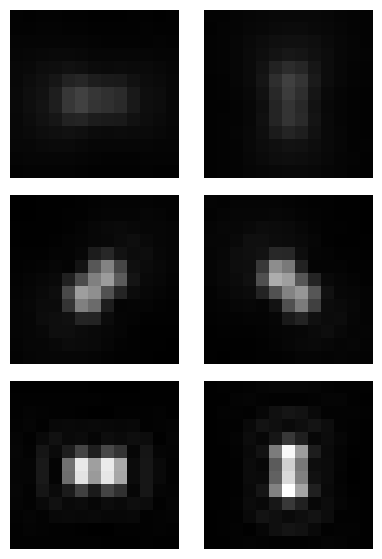

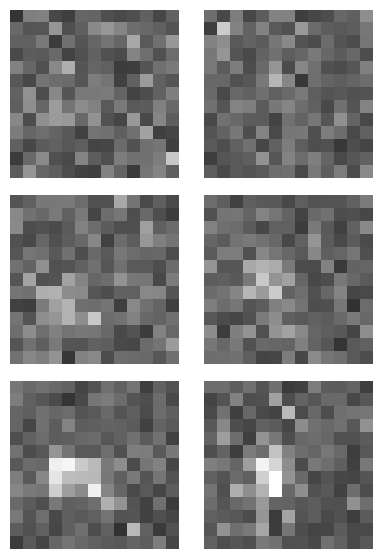

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.92it/s]


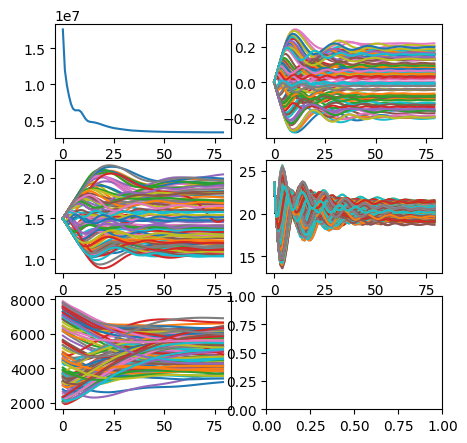

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.72it/s]


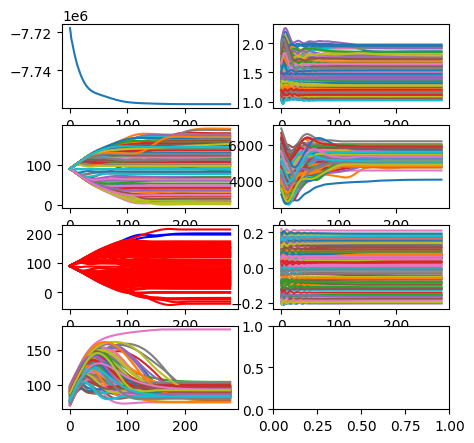

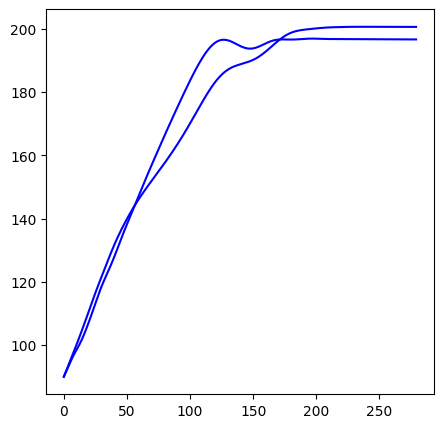

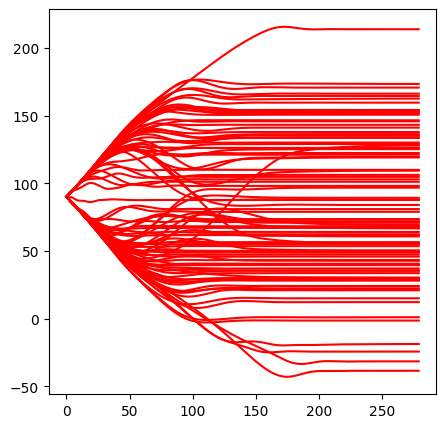

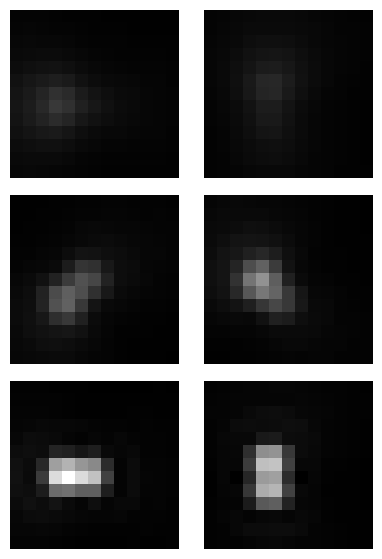

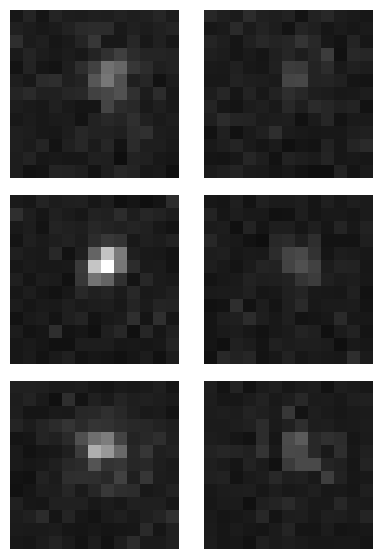

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.86it/s]


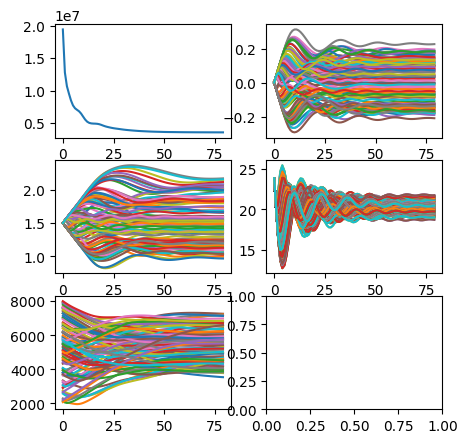

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.73it/s]


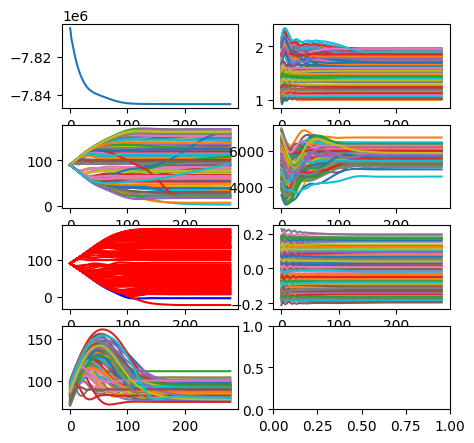

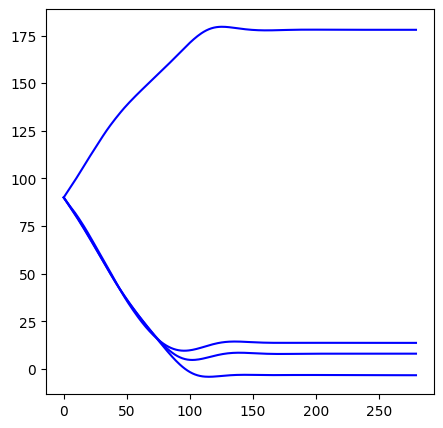

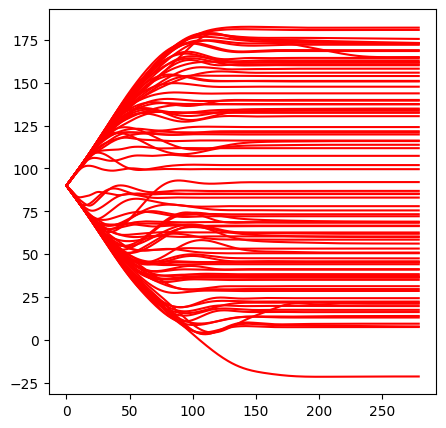

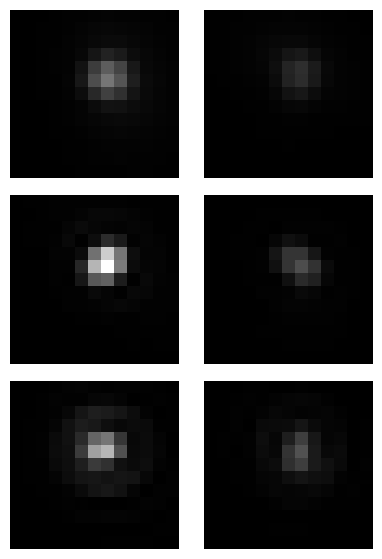

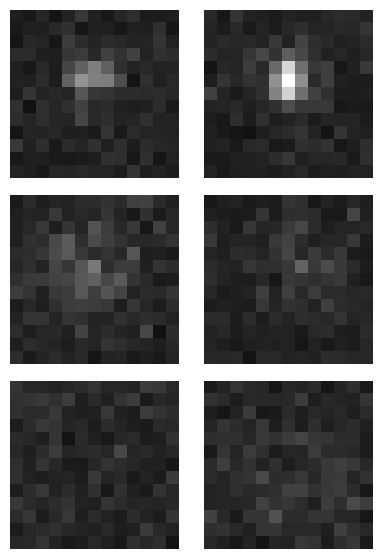

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.83it/s]


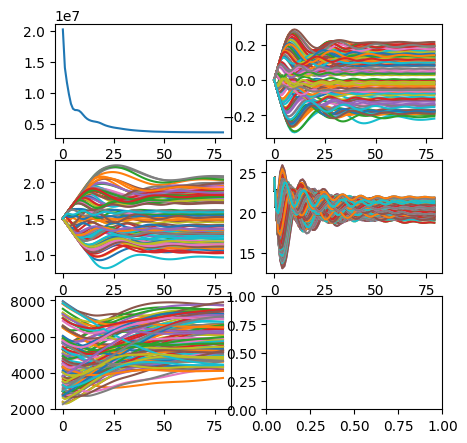

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.75it/s]


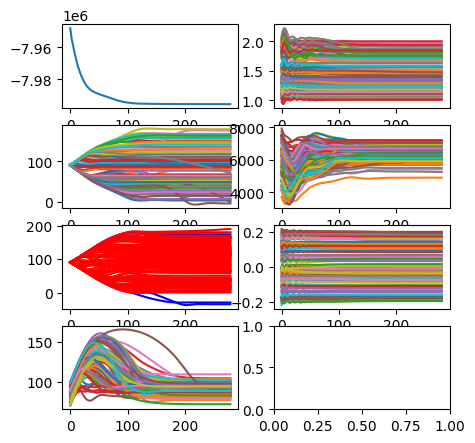

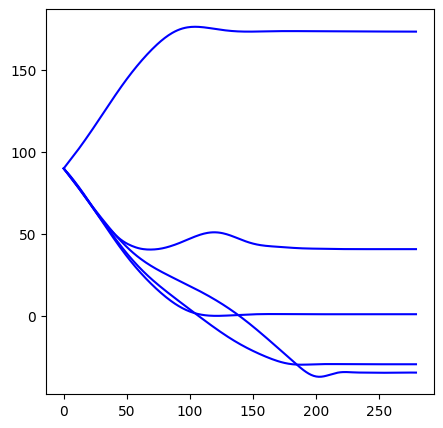

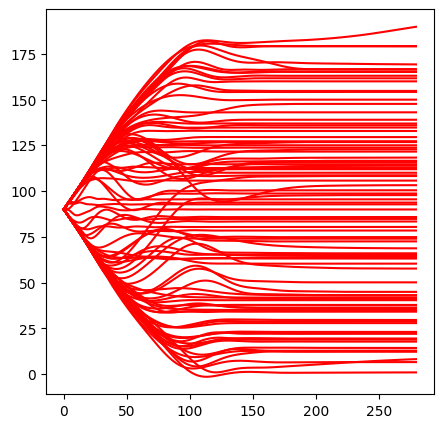

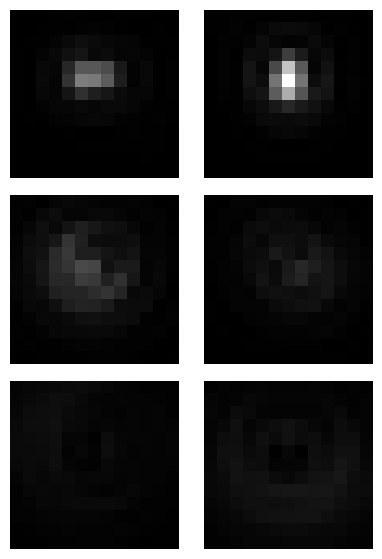

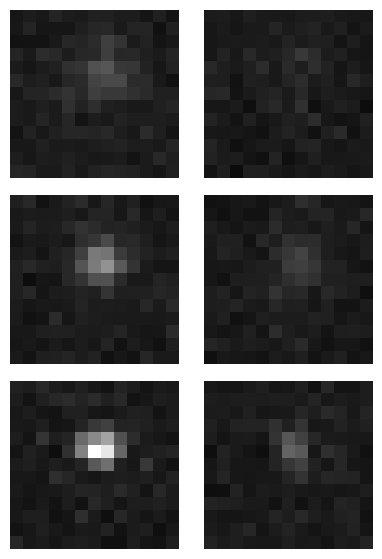

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.92it/s]


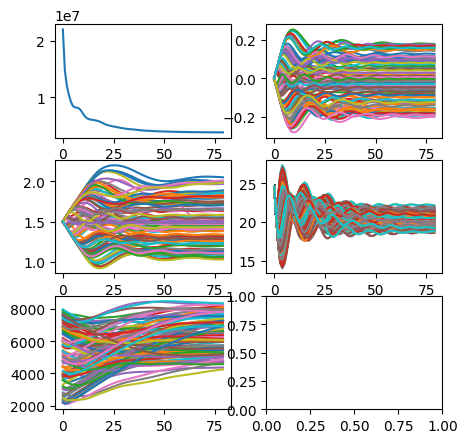

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.74it/s]


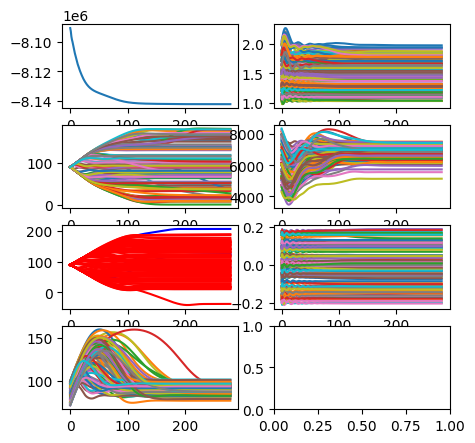

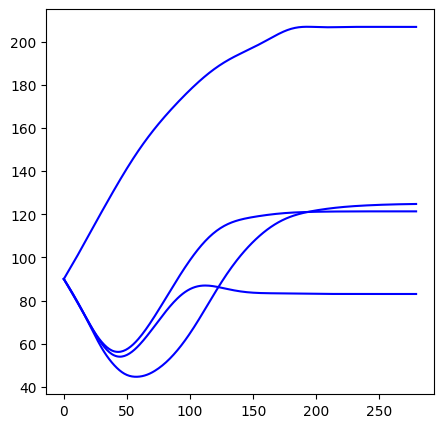

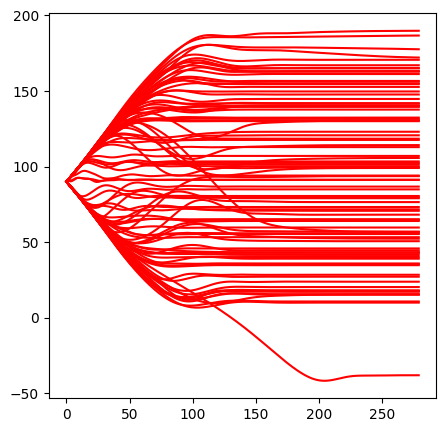

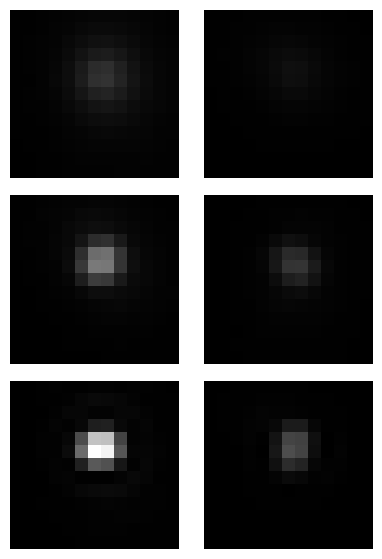

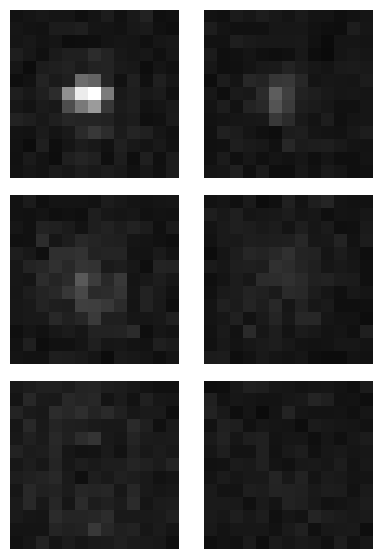

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.90it/s]


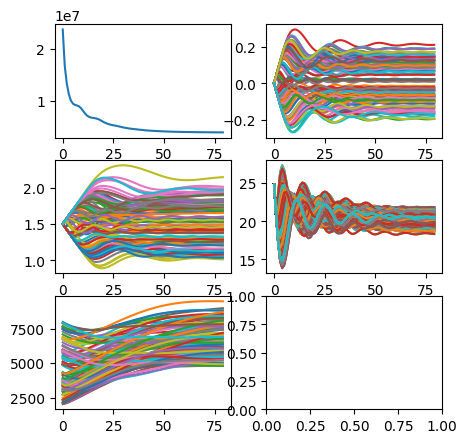

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.74it/s]


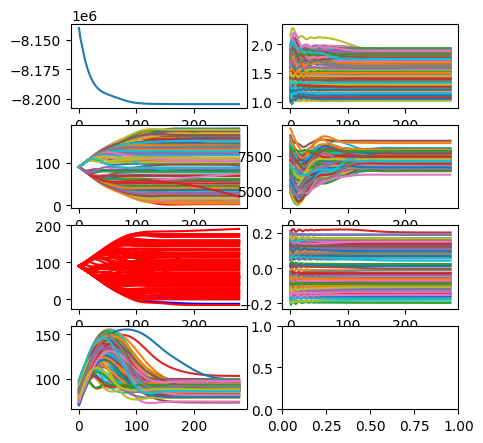

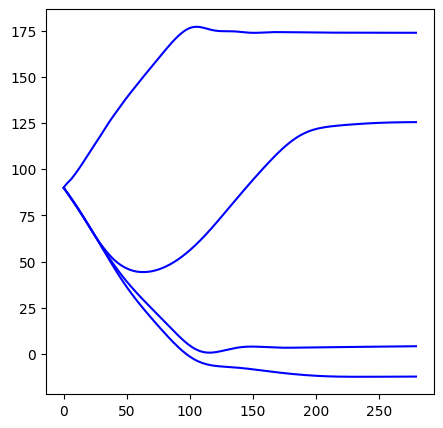

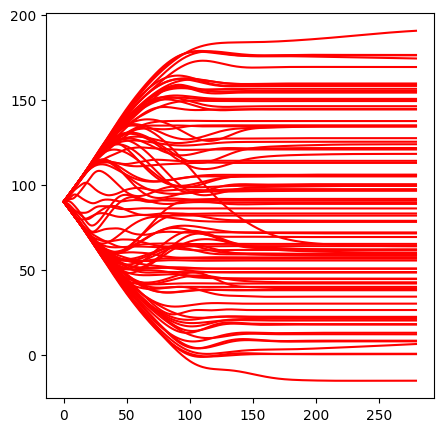

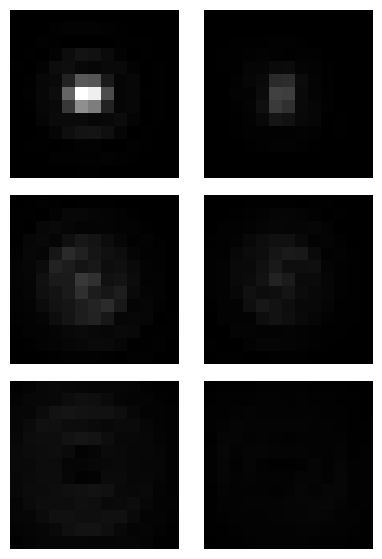

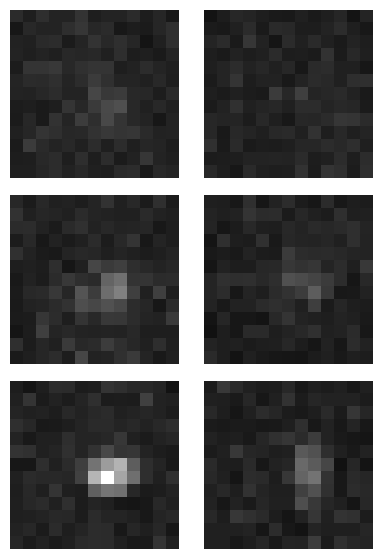

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.88it/s]


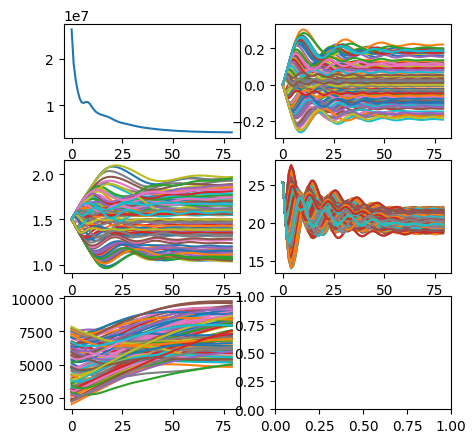

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.71it/s]


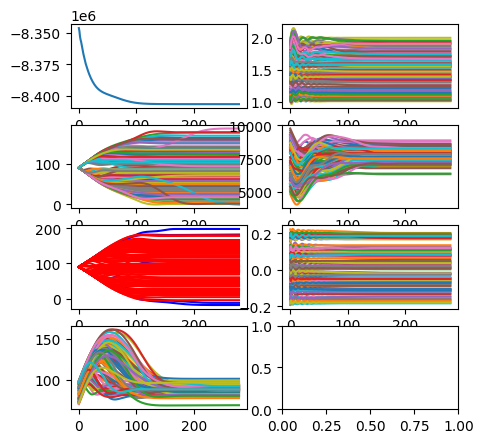

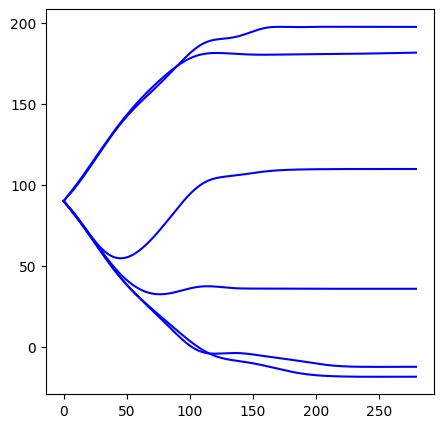

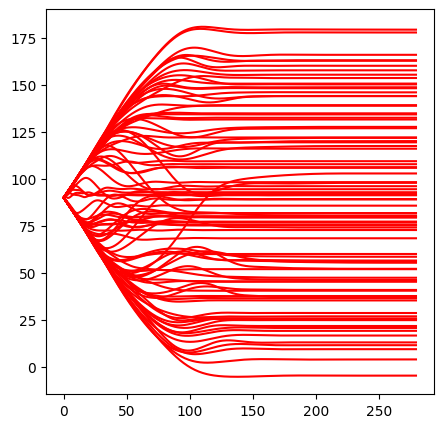

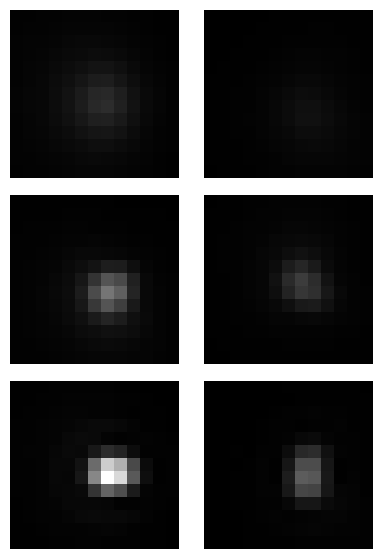

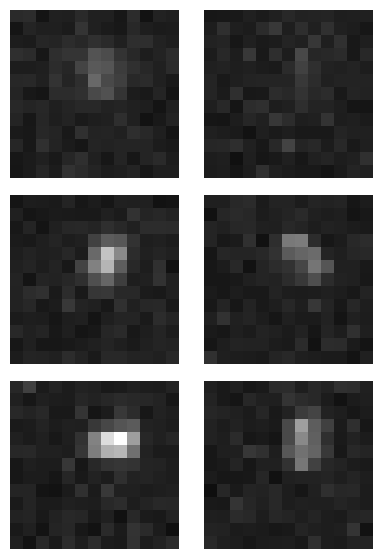

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.87it/s]


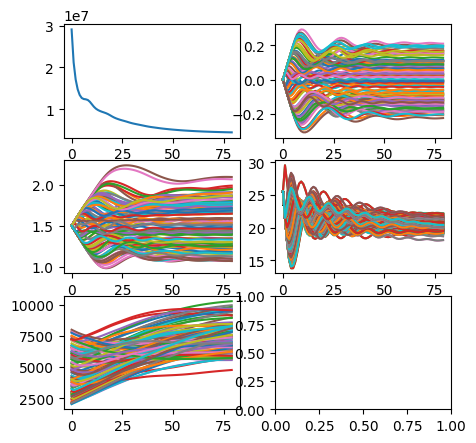

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.71it/s]


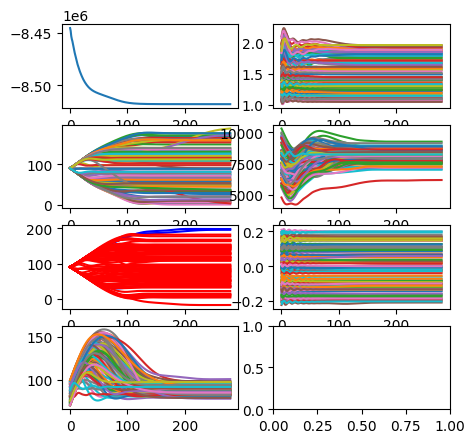

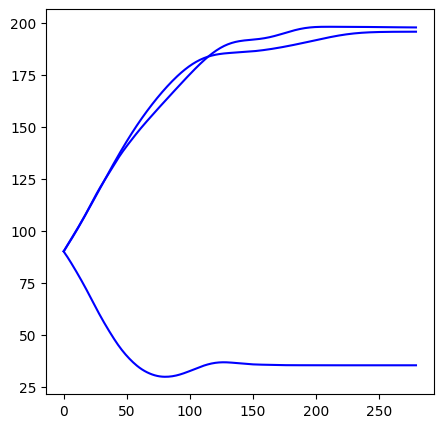

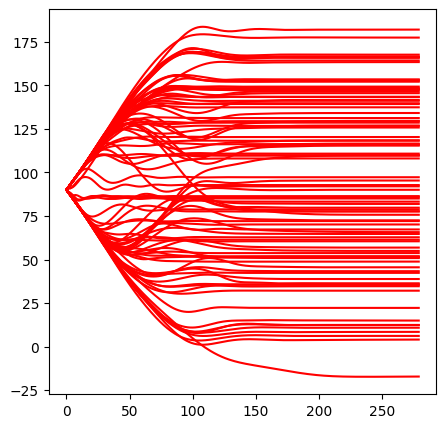

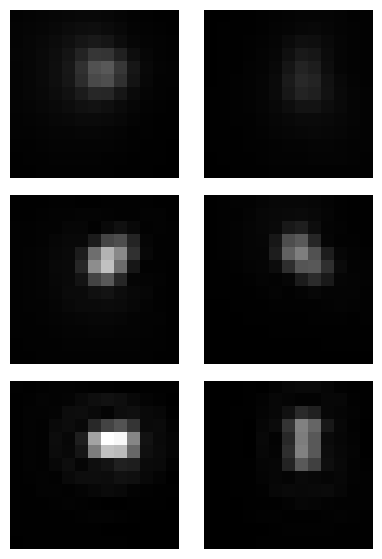

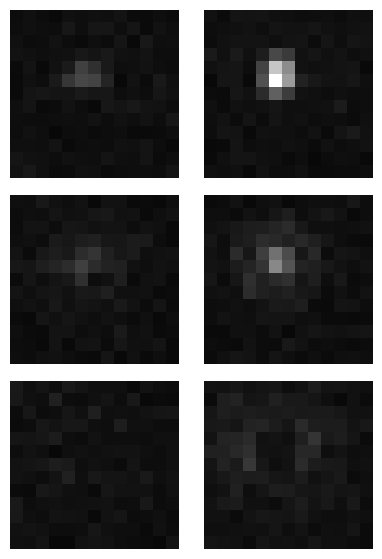

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.86it/s]


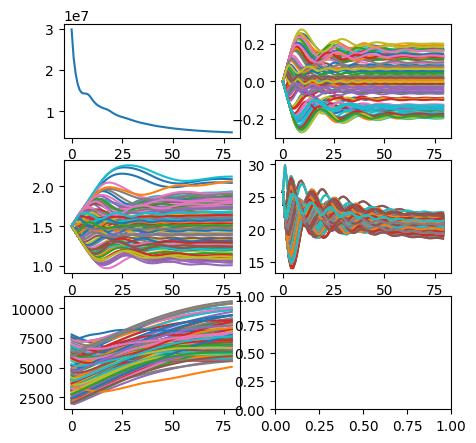

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.77it/s]


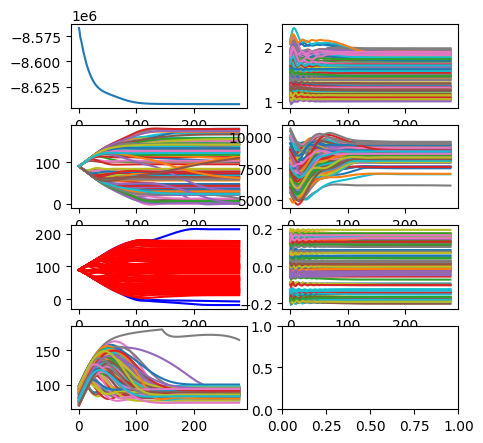

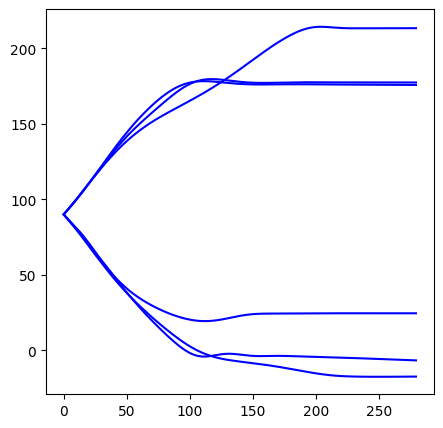

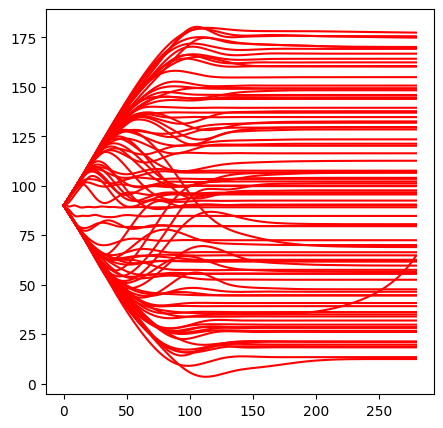

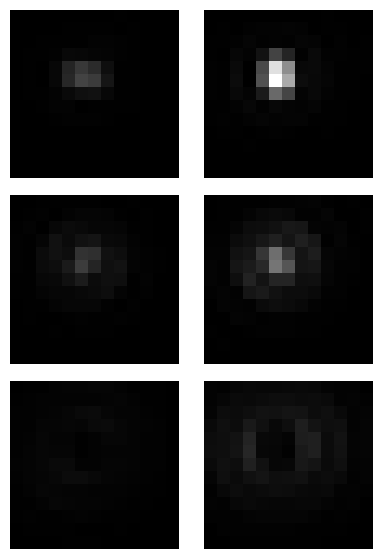

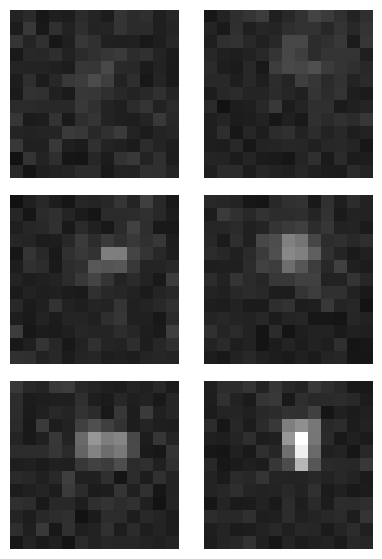

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.89it/s]


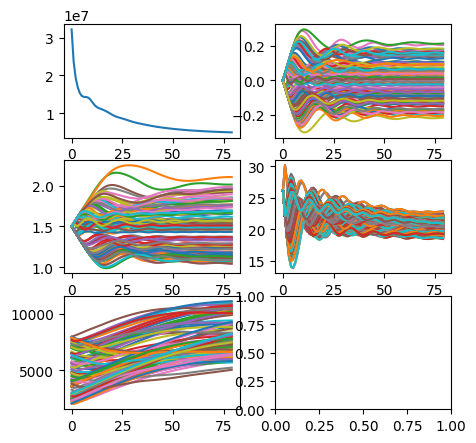

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.71it/s]


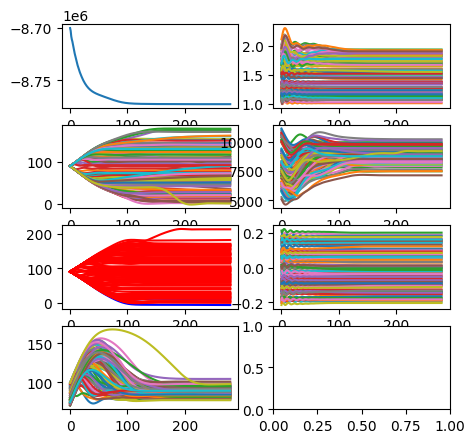

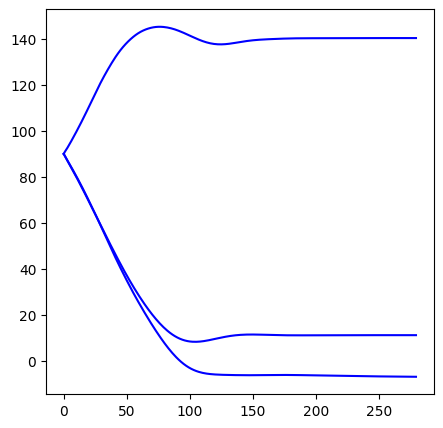

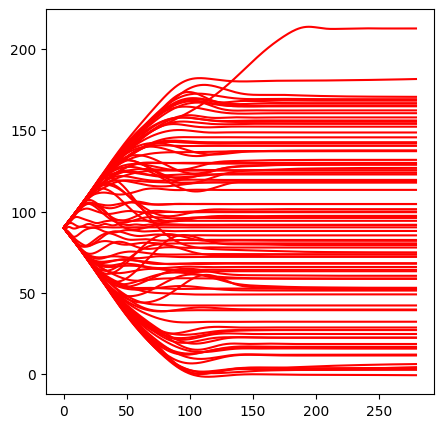

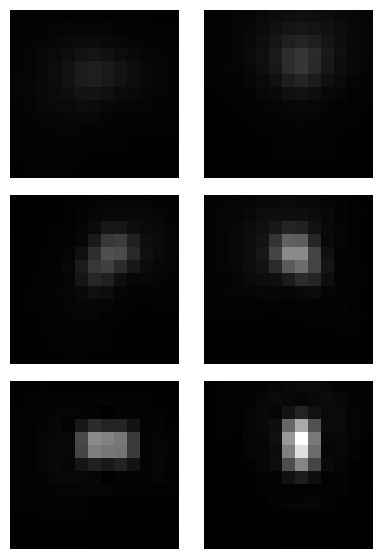

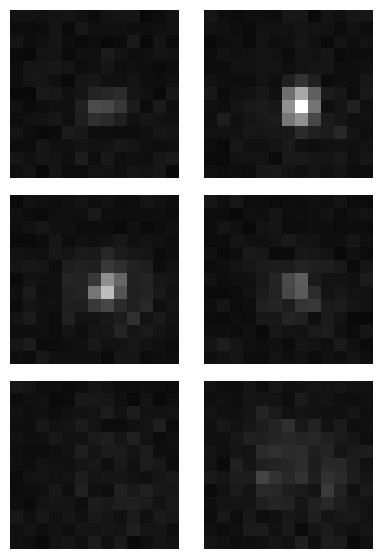

100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 12.86it/s]


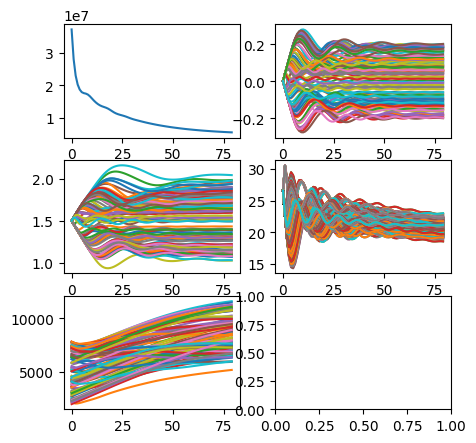

NPSF =  100


100%|█████████████████████████████████████████████████████████████████████████████████| 280/280 [00:36<00:00,  7.71it/s]


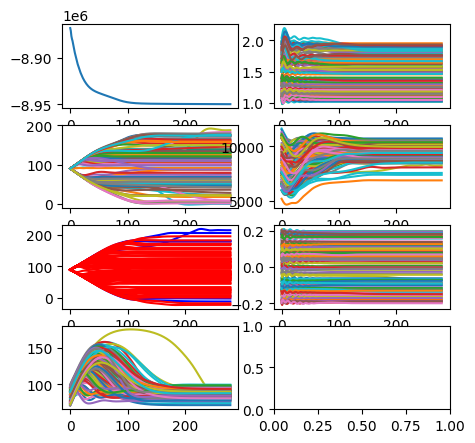

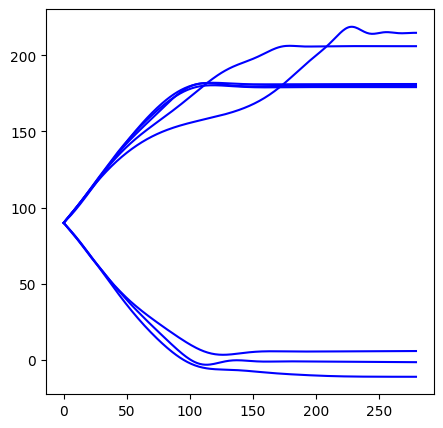

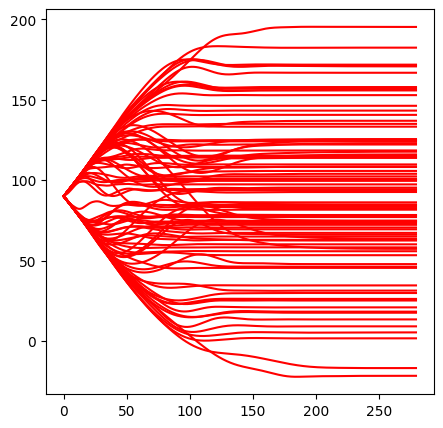

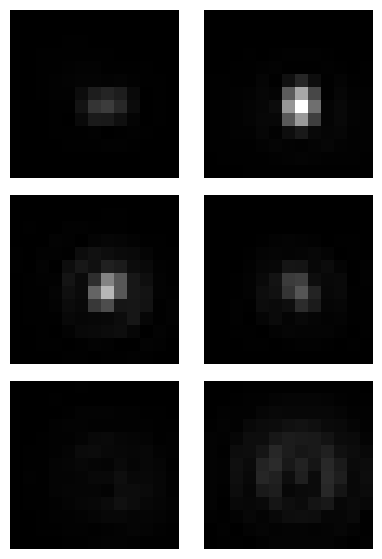

In [11]:
for N0 in N_photon_list:
    N=torch.tensor(80, device=device, requires_grad=False)
    l_pixel=torch.tensor(16, device=device, requires_grad=False)
    NA=torch.tensor(1.4, device=device, requires_grad=False)
    mag=torch.tensor(100, device=device, requires_grad=False)
    lambd=torch.tensor(625, device=device, requires_grad=False)
    f_tube=torch.tensor(200, device=device, requires_grad=False)
    MAG=torch.tensor(200/150, device=device, requires_grad=False)

    # microscope parameters
    d_ = -torch.tensor([d[1] for k in range(npsf)], requires_grad=False, device=device)
    second_plane = torch.tensor([d[1]-d[0], 0, d[1]-d[2]], device=device, requires_grad=False)
    polar_projections = np.array([0, 45, 0])
    
    SAF = False

    if SAF:
        xx, yy, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, r_cut_saf, k_, f_o, costh2 = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J_dichroic)
    else:
        costh2=None
        xx, yy, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k_, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J_dichroic)

    u, v, Npadding = padding(r, r_cut, k_, f_o,  N=N, l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, 
              f_tube=f_tube, MAG=MAG, device=device)

    phase_mask = torch.stack([torch.ones((N,N), device=device), torch.ones((N,N), device=device), torch.ones((N,N), device=device)])
    zernike_base = None
    
    xx = pad(xx, Npadding).to(torch.complex64).detach()
    yy = pad(yy, Npadding).to(torch.complex64).detach()
    th1 = pad(th1, Npadding).to(torch.complex64).detach()
    phi = pad(phi, Npadding).to(torch.complex64).detach()
    Ex0 = pad(Ex0, Npadding).to(torch.complex64).detach()
    Ex1 = pad(Ex1, Npadding).to(torch.complex64).detach()
    Ex2 = pad(Ex2, Npadding).to(torch.complex64).detach()
    Ey0 = pad(Ey0, Npadding).to(torch.complex64).detach()
    Ey1 = pad(Ey1, Npadding).to(torch.complex64).detach()
    Ey2 = pad(Ey2, Npadding).to(torch.complex64).detach()
    phase_mask = pad(phase_mask, Npadding).to(torch.complex64).detach()
    #zernike_base = pad(zernike_base, Npadding).to(torch.complex64).detach()
    if SAF:
        costh2 = pad(costh2, Npadding).to(torch.complex64).detach()

    x_true = torch.tensor(2*(np.random.rand(npsf)-0.5)*0.2).to(device)
    y_true = torch.tensor(2*(np.random.rand(npsf)-0.5)*0.2).to(device)
    z_true = torch.tensor(np.random.rand(npsf)*1.+1.).to(device)
    
    Mtrue = compute_M(xp=x_true, yp=y_true, zp=z_true, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=None,
                    second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, device=device, mode=mode)

    rho_true = torch.tensor(np.random.rand(npsf)*180).to(device)#torch.tensor([170 for i in range(npsf)]).to(device)#
    eta_true = torch.tensor(np.random.rand(npsf)*180).to(device)
    delta_true = torch.tensor([delta__ for uu in range(npsf)]).to(device)
    N_true = torch.tensor([N0 for uu in range(npsf)]).to(device) #3000-8000 #500-2500

    psf_ = PSF(rho=rho_true, eta=eta_true, delta=delta_true, M=Mtrue, N_photons=N_true).to(torch.float32)
    psf = noise(psf_, QE=QE, EM=EM, b=10., sigma_b=1., sigma_r=1., bias=10.)

    nx = psf.shape[-1]
    noisy_psf = psf[:,:,:,nx//2-6:nx//2+7,nx//2-6:nx//2+7].to(torch.float32) 

    sigma = 1. #torch.std(noisy_psf.flatten())
    background = torch.mean(noisy_psf.flatten())

    nb=0
    maxi = np.max(noisy_psf[nb,:,:].flatten().cpu().detach().numpy())
    fig, ax = plt.subplots(3,2, figsize=(5,7), gridspec_kw={'wspace':0, 'hspace':0.1})
    for ax_ in ax.flat:
        ax_.set_aspect('auto')
        ax_.axis('off')
    ax[0,0].imshow(noisy_psf[nb,0,0].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[1,0].imshow(noisy_psf[nb,1,0].cpu().detach().numpy() , vmin=0., vmax=maxi, cmap='gray')
    ax[2,0].imshow(noisy_psf[nb,2,0].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[0,1].imshow(noisy_psf[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[1,1].imshow(noisy_psf[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[2,1].imshow(noisy_psf[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    plt.show()
    del(fig, ax)

    # nb of photons by plane roughly evaluated
    Nstart_by_plane = copy.deepcopy(torch.sum(noisy_psf, axis=(2,3,4)) - background*len(noisy_psf[0,0].flatten()))

    NPSF = noisy_psf.shape[0]

    # strating parameters (could be a first evaluation with coarse algo)
    x_start = torch.tensor([0. for k in range(NPSF)], requires_grad=False, device=device)
    y_start = torch.tensor([0. for k in range(NPSF)], requires_grad=False, device=device)
    z_exp =  torch.tensor([1.5 for k in range(NPSF)], requires_grad=False, device=device) 

    # convert to tensor
    #noisy_psf = torch.tensor(np.array([single_psf[k] for k in range(len(x))]), device=device, dtype=torch.float32)

    # starting point, could do a rough estimation first
    rho_start = torch.tensor([90. for i in range(npsf)], device=device).to(torch.float32)#np.random.rand(npsf)*180, device=device).to(torch.float32)
    eta_start = torch.tensor([90. for i in range(npsf)], device=device).to(torch.float32)#np.random.rand(npsf)*180, requires_grad=False, device=device).to(torch.float32)
    delta_start = torch.tensor(np.random.rand(npsf)*30+70, device=device).to(torch.float32)

    # gradient descent parameters
    Nstart = torch.tensor(2000.+np.random.rand(npsf)*6000, device=device).to(torch.float32)
    #Nstart = copy.deepcopy(torch.sum(noisy_psf, dim=(1,2,3,4)) - background*len(noisy_psf[0].flatten()))
    
    Mtest = compute_M(xp=x_start, yp=y_start, zp=z_exp, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2, Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=None, zernike_coefs_x=None, zernike_coefs_y=None,
                        second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, device=device, mode=mode)
    
    htest = PSF(rho=rho_start, eta=eta_start, delta=delta_start, M=Mtest, N_photons=Nstart).to(torch.float32)
    
    dim_simu = int(htest.shape[-1]//2)

    background_array = (background*torch.ones((NPSF,3,2)).to(device)).to(torch.float32)
    params = torch.cat((x_start, y_start, z_exp, Nstart/Nphotons_speed1, background_array.flatten()/background_speed)).to(torch.float32)
    params.requires_grad=True

    angle_rd = torch.tensor([180. for k in range(NPSF)], requires_grad=False, device=device).to(torch.float32)
    optimizer = torch.optim.Adam([params], lr=LR1)
    loss_ = []
    z__ = []
    N__ = []
    x__ =[]
    bck=[]
    for i in tqdm(range(num_epochs_max1)):
        optimizer.zero_grad()  # Reset gradients
        loss = loss_pos(params[0:NPSF], params[NPSF:2*NPSF], params[2*NPSF:3*NPSF], 
                           angle_rd, angle_rd, angle_rd, params[3*NPSF:4*NPSF]*Nphotons_speed1, 
                           noisy_psf, second_plane, params[4*NPSF:10*NPSF]*background_speed, sigma, dim_simu, plot=False)
        loss_.append(loss.cpu().detach().numpy())
        z__.append(params[2*NPSF:3*NPSF].cpu().detach().numpy())
        N__.append((params[3*NPSF:4*NPSF]*Nphotons_speed1).cpu().detach().numpy())
        x__.append((params[0*NPSF:1*NPSF]).cpu().detach().numpy())
        bck.append((params[4*NPSF:10*NPSF]*background_speed).cpu().detach().numpy())
        loss.backward()
        optimizer.step()
    fig, ax = plt.subplots(3,2)
    ax[0,0].plot(loss_)
    ax[1,0].plot(z__)
    ax[2,0].plot(N__)
    ax[0,1].plot(x__)
    ax[1,1].plot(bck)
    plt.show()
    del(ax, loss_, z__, N__)

    x_found = params[0:NPSF].detach()
    y_found = params[NPSF:2*NPSF].detach()
    z_found = params[2*NPSF:3*NPSF].detach()
    N_found = params[3*NPSF:4*NPSF].detach()*Nphotons_speed1
    bacground_array_found = params[4*NPSF:10*NPSF].detach()*background_speed
    del(params, loss)
    print('NPSF = ', NPSF)

#########################################################################################################################

    zern_x = torch.tensor(np.zeros(3*15), device=device)
    zern_y = torch.tensor(np.zeros(3*15), device=device)

    params = torch.cat((rho_start, eta_start, delta_start/delta_speed, N_found/nphotons_speed2, x_found/xy_speed2, y_found/xy_speed2, z_found/z_speed2))
    params.requires_grad=True

    # Use Stochastic Gradient Descent (SGD) to optimize params
    optimizer = torch.optim.Adam([params], lr=LR2)  # Learning rate = 0.01

    loss_ = []
    eta_ = []
    rho_ = []
    delta_ = []
    z__ = []
    N__ = []
    x__ =[]
    for i in tqdm(range(num_epochs_max2)):
        optimizer.zero_grad()  # Reset gradients
        loss = loss_angle_with_M(params[:NPSF], params[1*NPSF:2*NPSF], params[2*NPSF:3*NPSF]*delta_speed, params[3*NPSF:4*NPSF]*nphotons_speed2, params[4*NPSF:5*NPSF]*xy_speed2, params[5*NPSF:6*NPSF]*xy_speed2, params[6*NPSF:7*NPSF]*z_speed2, zern_x, zern_y, noisy_psf, bacground_array_found, sigma, dim_simu)
        loss_.append(loss.cpu().detach().numpy())
        eta_.append((params[1*NPSF:2*NPSF]).cpu().detach().numpy())
        rho_.append((params[0*NPSF:1*NPSF]).cpu().detach().numpy())
        delta_.append((params[2*NPSF:3*NPSF]).cpu().detach().numpy())
        z__.append((params[6*NPSF:7*NPSF]).cpu().detach().numpy())
        N__.append((params[3*NPSF:4*NPSF]).cpu().detach().numpy())
        x__.append((params[4*NPSF:5*NPSF]).cpu().detach().numpy())
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters
    plt.rcParams['figure.figsize'] = [5,5]
    fig, ax = plt.subplots(4,2)
    ax[0,0].plot(loss_) 
    #ax[0,0].set_ylim((np.min(np.array(loss_)), np.max(np.array(loss_))))
    ax[1,0].plot(rho_)
    ax[2,0].plot(np.array(eta_)[:,np.abs((params[0*NPSF:1*NPSF]-rho_true).cpu().detach().numpy())>90], c='b')
    ax[2,0].plot(np.array(eta_)[:,np.abs((params[0*NPSF:1*NPSF]-rho_true).cpu().detach().numpy())<90], c='r')
    ax[3,0].plot(np.array(delta_)*delta_speed)
    ax[0,1].plot(np.array(z__)*z_speed2) 
    ax[1,1].plot(np.array(N__)*nphotons_speed2)
    ax[2,1].plot(np.array(x__)*xy_speed2)
    plt.show()
    del(fig, ax)
    plt.plot(np.array(eta_)[:,np.abs((params[0*NPSF:1*NPSF]-rho_true).cpu().detach().numpy())>90], c='b')
    plt.show()
    plt.plot(np.array(eta_)[:,np.abs((params[0*NPSF:1*NPSF]-rho_true).cpu().detach().numpy())<90], c='r')
    plt.show()

    x_found = params[4*NPSF:5*NPSF].detach()*xy_speed2
    y_found = params[5*NPSF:6*NPSF].detach()*xy_speed2
    z_found = params[6*NPSF:7*NPSF].detach()*z_speed2
    N_found = params[3*NPSF:4*NPSF].detach()*nphotons_speed2
    rho_found=params[0:NPSF].detach()
    eta_found=params[1*NPSF:2*NPSF].detach()
    delta_found=params[2*NPSF:3*NPSF].detach()*delta_speed
    
    del(params, loss, eta_, loss_)
    Mfound = compute_M(xp=x_found, yp=y_found, zp=z_found, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2, Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=None,second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, device=device, mode=mode)

    psf_ = PSF(rho=rho_found, eta=eta_found, delta=delta_found, M=Mfound, N_photons=N_found).to(torch.float32)
    psf = psf_[:,:,:,nx//2-6:nx//2+7,nx//2-6:nx//2+7].to(torch.float32)
    nx = psf.shape[-1]
    nb=0
    maxi = np.max(psf[nb,:,:].flatten().cpu().detach().numpy())
    fig, ax = plt.subplots(3,2, figsize=(5,7), gridspec_kw={'wspace':0, 'hspace':0.1})
    for ax_ in ax.flat:
        ax_.set_aspect('auto')
        ax_.axis('off')
    ax[0,0].imshow(psf[nb,0,0].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[1,0].imshow(psf[nb,1,0].cpu().detach().numpy() , vmin=0., vmax=maxi, cmap='gray')
    ax[2,0].imshow(psf[nb,2,0].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[0,1].imshow(psf[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[1,1].imshow(psf[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    ax[2,1].imshow(psf[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi, cmap='gray')
    plt.show()
    del(fig, ax)
    np.savez_compressed('/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/files_papier/read10_bck10_poisson/N_'+str(N0)+'.npz', 
                        x_true=x_true.detach().cpu().numpy(), y_true=y_true.detach().cpu().numpy(), z_true=z_true.detach().cpu().numpy(),
                        N_true=N_true.detach().cpu().numpy(), rho_true=rho_true.detach().cpu().numpy(), eta_true=eta_true.detach().cpu().numpy(),
                        delta_true=delta_true.detach().cpu().numpy(),
                        x_found=x_found.detach().cpu().numpy(), y_found=y_found.detach().cpu().numpy(), z_found=z_found.detach().cpu().numpy(),
                        N_found=N_found.detach().cpu().numpy(), rho_found=rho_found.detach().cpu().numpy(), eta_found=eta_found.detach().cpu().numpy(),
                        delta_found=delta_found.detach().cpu().numpy())
    

In [46]:
folder = '/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/files_papier/read10_bck10_poisson/'
x_true = []
y_true = []
z_true = []
rho_true = []
eta_true = []
delta_true = []
N_true = []
x_found = []
y_found = []
z_found = []
rho_found = []
eta_found = []
delta_found = []
N_found = []
pattern = re.compile(r"N_([-+]?\d*\.?\d+)")

files = sorted(
    os.listdir(folder),
    key=lambda f: (
        float(pattern.search(f).group(1)),  # N
    )
)

for filename in files:
    data = np.load(os.path.join(folder, filename))
    x_true.append(data['x_true'])
    y_true.append(data['y_true'])
    z_true.append(data['z_true'])
    rho_true.append(data['rho_true'])
    eta_true.append(data['eta_true'])
    delta_true.append(data['delta_true'])
    N_true.append(data['N_true'])
    x_found.append(data['x_found'])
    y_found.append(data['y_found'])
    z_found.append(data['z_found'])
    rho_found.append(data['rho_found'])
    eta_found.append(data['eta_found'])
    delta_found.append(data['delta_found'])
    N_found.append(data['N_found'])

x_true = np.array(x_true)
y_true = np.array(y_true)
z_true = np.array(z_true)
rho_true = np.array(rho_true)
eta_true = np.array(eta_true)
delta_true = np.array(delta_true)
N_true = np.array(N_true)
x_found = np.array(x_found)
y_found = np.array(y_found)
z_found = np.array(z_found)
rho_found = np.array(rho_found)
eta_found = np.array(eta_found)
delta_found = np.array(delta_found)
N_found = np.array(N_found)

In [47]:
mask0 = (rho_found>180) | (rho_found<0)
rho_found[mask0] = rho_found[mask0]%180
eta_found[mask0] = 180-(eta_found[mask0])

In [48]:
deltax = x_found-x_true
deltay = y_found-y_true
deltaz = z_found - z_true
deltarho = rho_found - rho_true
deltadelta = delta_found-delta_true
deltaN = N_found-N_true

In [49]:
mask1 = deltarho > 90
deltarho[mask1] = deltarho[mask1]-180
mask2 = deltarho < -90
deltarho[mask2] = deltarho[mask2]+180

In [50]:
eta_found[mask1] = 180-eta_found[mask1]
eta_found[mask2] = 180-eta_found[mask2]

In [51]:
deltaeta = eta_found-eta_true

In [52]:
mask1 = deltaeta > 90
deltaeta[mask1] = deltaeta[mask1]-180
mask2 = deltaeta < -90
deltaeta[mask2] = deltaeta[mask2]+180

In [19]:
deltarho_LMS = deltarho
deltaeta_LMS = deltaeta
deltadelta_LMS = deltadelta
deltaN_LMS = deltaN
deltax_LMS = deltax
deltay_LMS = deltay
deltaz_LMS = deltaz

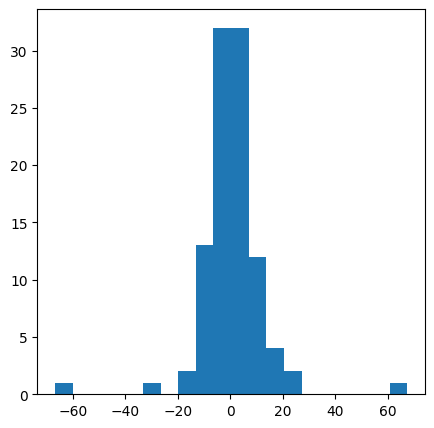

In [33]:
hh = plt.hist(deltaeta[5], bins=20)

In [36]:
def iq(series):
    res = []
    for i in range(series.shape[0]):
        res.append(np.percentile(series[i], 75)-np.percentile(series[i], 25))
    return np.array(res)

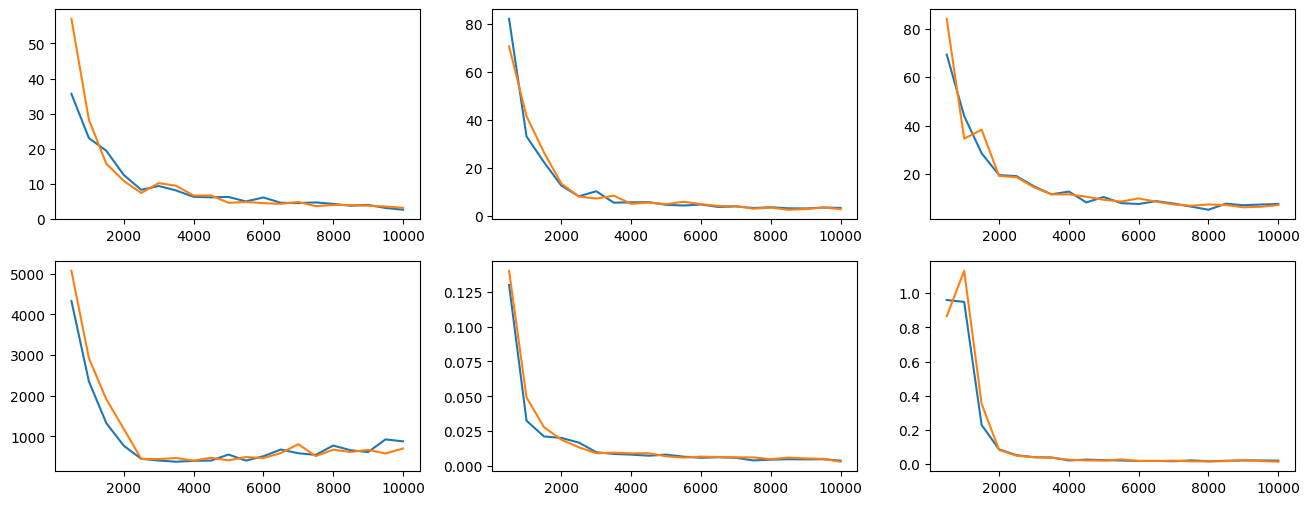

In [53]:
fig, ax = plt.subplots(2, 3, figsize=(16, 6))
ax[0,0].plot(N_photon_list, iq(deltarho))
ax[0,0].plot(N_photon_list, iq(deltarho_LMS))
ax[0,1].plot(N_photon_list, iq(deltaeta))
ax[0,1].plot(N_photon_list, iq(deltaeta_LMS))
ax[0,2].plot(N_photon_list, iq(deltadelta))
ax[0,2].plot(N_photon_list, iq(deltadelta_LMS))
ax[1,0].plot(N_photon_list, iq(deltaN))
ax[1,0].plot(N_photon_list, iq(deltaN_LMS))
ax[1,1].plot(N_photon_list, iq(deltax))
ax[1,1].plot(N_photon_list, iq(deltax_LMS))
ax[1,2].plot(N_photon_list, iq(deltaz))
ax[1,2].plot(N_photon_list, iq(deltaz_LMS))

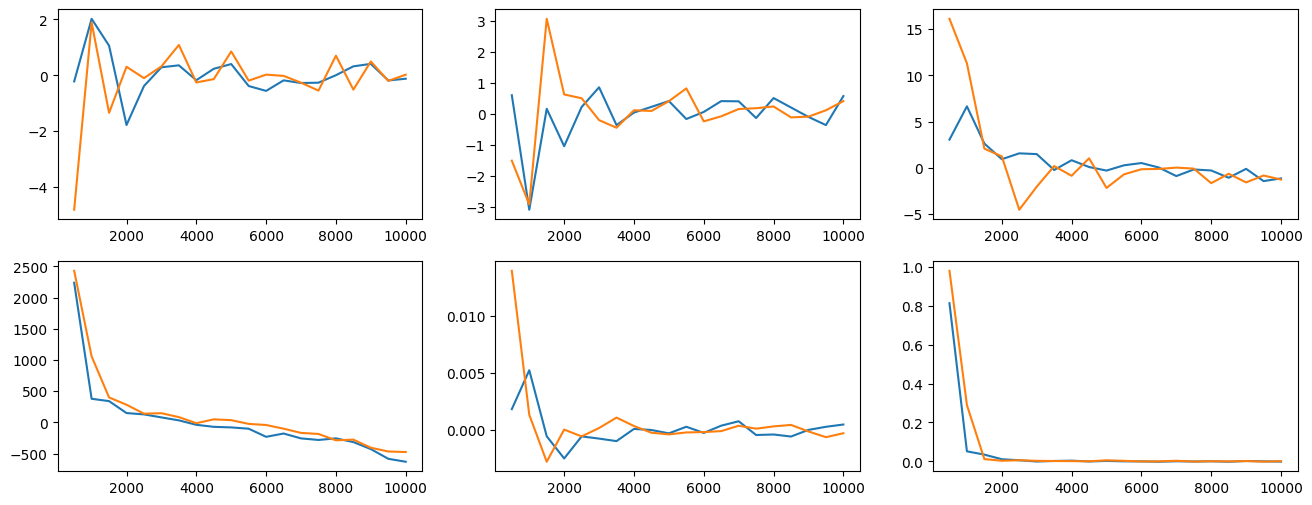

In [38]:
fig, ax = plt.subplots(2, 3, figsize=(16, 6))
ax[0,0].plot(N_photon_list, np.median(deltarho, axis=1))
ax[0,0].plot(N_photon_list, np.median(deltarho_LMS, axis=1))
ax[0,1].plot(N_photon_list, np.median(deltaeta, axis=1))
ax[0,1].plot(N_photon_list, np.median(deltaeta_LMS, axis=1))
ax[0,2].plot(N_photon_list, np.median(deltadelta, axis=1))
ax[0,2].plot(N_photon_list, np.median(deltadelta_LMS, axis=1))
ax[1,0].plot(N_photon_list, np.median(deltaN, axis=1))
ax[1,0].plot(N_photon_list, np.median(deltaN_LMS, axis=1))
ax[1,1].plot(N_photon_list, np.median(deltax, axis=1))
ax[1,1].plot(N_photon_list, np.median(deltax_LMS, axis=1))
ax[1,2].plot(N_photon_list, np.median(deltaz, axis=1))
ax[1,2].plot(N_photon_list, np.median(deltaz_LMS, axis=1))